<a href="https://colab.research.google.com/github/rtajeong/M4_2026/blob/main/lab_92_GAN_with_fashionMNIST_rev1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# GAN with fashion-MNIST
- https://machinelearningmastery.com/how-to-develop-a-conditional-generative-adversarial-network-from-scratch/



In [ ]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [5]:
from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Reshape, Flatten, Input
from tensorflow.keras.layers import Conv2D, Conv2DTranspose
from tensorflow.keras.layers import LeakyReLU, Dropout
import tensorflow as tf
from tensorflow import keras

(trainX, trainy), (testX, testy) = fashion_mnist.load_data()

print('Train', trainX.shape, trainy.shape)
print('Test', testX.shape, testy.shape)

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Train (60000, 28, 28) (60000,)
Test (10000, 28, 28) (10000,)


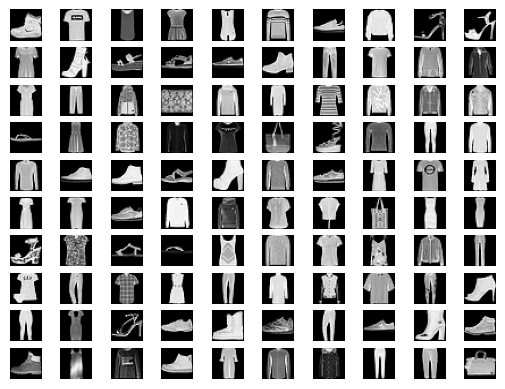

In [ ]:
for i in range(100):
	plt.subplot(10, 10, 1 + i)
	plt.axis('off')
	plt.imshow(trainX[i], cmap='gray')  # cmap = gray or gray_r
plt.show()

In [ ]:
set(trainy)

{np.uint8(0),
 np.uint8(1),
 np.uint8(2),
 np.uint8(3),
 np.uint8(4),
 np.uint8(5),
 np.uint8(6),
 np.uint8(7),
 np.uint8(8),
 np.uint8(9)}

## Unconditional GAN

In [ ]:
def define_discriminator(in_shape=(28,28,1)):
    model = Sequential()
    model.add(Input(shape=in_shape))
    model.add(Conv2D(128, (3,3), strides=(2,2), padding='same'))
    model.add(LeakyReLU(alpha=0.2))
    model.add(Conv2D(128, (3,3), strides=(2,2), padding='same'))
    model.add(LeakyReLU(alpha=0.2))
    model.add(Flatten())
    model.add(Dropout(0.4))
    model.add(Dense(1, activation='sigmoid'))

    opt = Adam(learning_rate=0.0002, beta_1=0.5)
    model.compile(loss='binary_crossentropy', optimizer=opt, metrics=['accuracy'])

    return model

Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_12 (Conv2D)              │ (None, 14, 14, 128)    │         1,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_20 (LeakyReLU)      │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 7, 7, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_21 (LeakyReLU)      │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │         6,273 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 155,137 (606.00 KB)

 Trainable params: 155,137 (606.00 KB)

 Non-trainable params: 0 (0.00 B)

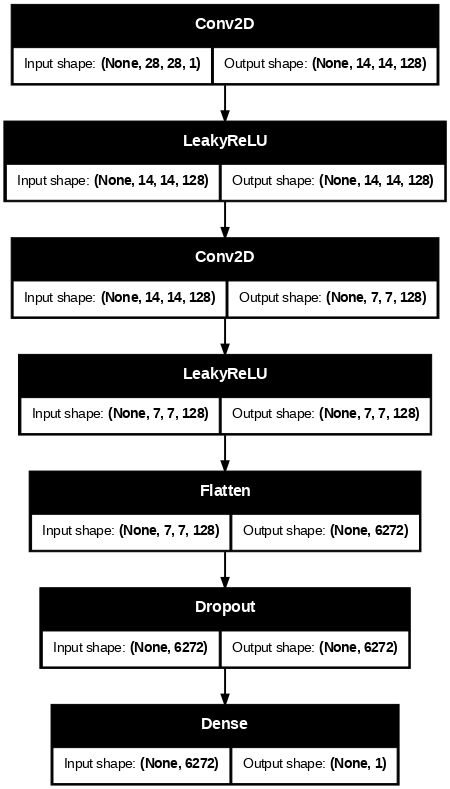

In [ ]:
define_discriminator().summary()
keras.utils.plot_model(define_discriminator(), "gan_encoder.png", show_shapes=True, dpi=70)

- not compiled yet (intentionally), and returns the model

In [ ]:
# take as input a point in the latent space and outputs a single 28x28 grayscale image
def define_generator(latent_dim):
	model = Sequential()
	# foundation for 7x7 image
	n_nodes = 128 * 7 * 7
	model.add(Input(shape=(latent_dim,)))    # 7*7 -> 14*14 -> 28*28 upsampling 하기 위해
	model.add(Dense(n_nodes))                # 7x7x128 크기의 feature map 으로 변환
	model.add(LeakyReLU(alpha=0.2))
	model.add(Reshape((7, 7, 128)))
	model.add(Conv2DTranspose(128, (4,4), strides=(2,2), padding='same')) # upsample to 14x14
	model.add(LeakyReLU(alpha=0.2))
	model.add(Conv2DTranspose(128, (4,4), strides=(2,2), padding='same')) # upsample to 28x28
	model.add(LeakyReLU(alpha=0.2))
	model.add(Conv2D(1, (7,7), activation='tanh', padding='same'))        # generate
	return model

/usr/local/lib/python3.12/dist-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


Model: "sequential_12"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_10 (Dense)                │ (None, 6272)           │       633,472 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_24 (LeakyReLU)      │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_4 (Reshape)             │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_8              │ (None, 14, 14, 128)    │       262,272 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_25 (LeakyReLU)      │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_9              │ (None, 28, 28, 128)    │       262,272 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_26 (LeakyReLU)      │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 28, 28, 1)      │         6,273 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,164,289 (4.44 MB)

 Trainable params: 1,164,289 (4.44 MB)

 Non-trainable params: 0 (0.00 B)

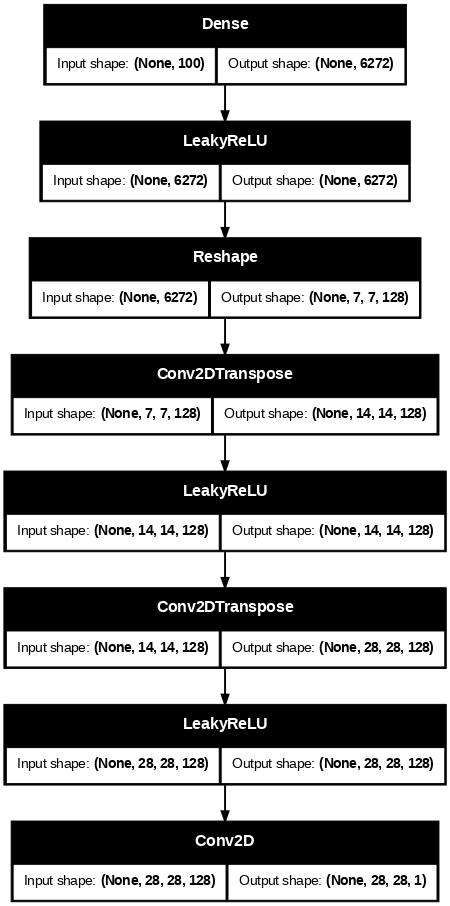

In [ ]:
latent_dim = 100
define_generator(latent_dim).summary()
keras.utils.plot_model(define_generator(latent_dim), "gan_decoder.png", show_shapes=True, dpi=70)

In [ ]:
# define the combined generator and discriminator model, for updating the generator
def define_gan(generator, discriminator):
	# make weights in the discriminator not trainable
	discriminator.trainable = False
	# connect them
	model = Sequential()
	model.add(generator)
	model.add(discriminator)
	opt = Adam(learning_rate=0.0002, beta_1=0.5)
	model.compile(loss='binary_crossentropy', optimizer=opt)
	return model

/usr/local/lib/python3.12/dist-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


Model: "sequential_16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_14 (Sequential)      │ (None, 28, 28, 1)      │     1,164,289 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_15 (Sequential)      │ (None, 1)              │       155,137 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,319,426 (5.03 MB)

 Trainable params: 1,164,289 (4.44 MB)

 Non-trainable params: 155,137 (606.00 KB)

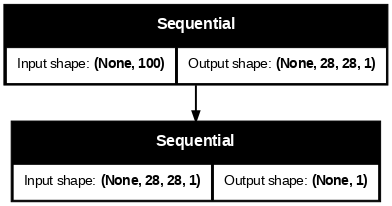

In [ ]:
all = define_gan(define_generator(100), define_discriminator())
all.summary()
keras.utils.plot_model(all, "all.png", show_shapes=True, dpi=70)

In [ ]:
# load fashion mnist images
def load_real_samples():
	(trainX, _), (_, _) = fashion_mnist.load_data()
	X = np.expand_dims(trainX, axis=-1)   # expand to 3d, e.g. add channels (60000,28,28,1)
	X = X.astype('float32')               # convert from ints to floats
	X = (X - 127.5) / 127.5               # scale from [0,255] to [-1,1]
	return X

- 입력 데이터의 Scaling
  - (0, 1) 스케일 — sigmoid와 짝
  - (-1, 1) 스케일 — tanh와 짝
- GAN에서 sigmoid 대신 tanh를 즐겨 쓰는 이유는:
  - tanh는 0을 중심으로 대칭이라서, BatchNormalization(역시 평균 0 근처로 정규화하는 레이어)과 궁합이 좋고, sigmoid보다 그래디언트가 더 강하게 흘러서(saturation이 덜 심해서) 학습이 좀 더 안정적이라는 게 GAN 논문들에서 경험적으로 알려짐.

- We will require one batch (or a half) batch of real images from the dataset each update to the GAN model. A simple way to achieve this is to select a random sample of images from the dataset each time.

In [ ]:
# select real samples
def generate_real_samples(dataset, n_samples):
	# choose random instances
	ix = np.random.randint(0, dataset.shape[0], n_samples)
	# select images
	X = dataset[ix]
	# generate class labels
	y = np.ones((n_samples, 1))   # y_real = 1
	return X, y

- Next, we need inputs for the generator model. These are random points from the latent space, specifically Gaussian distributed random variables.

In [ ]:
# generate points in latent space as input for the generator
def generate_latent_points(latent_dim, n_samples):
	# generate points in the latent space
	x_input = np.random.randn(latent_dim * n_samples)
	# reshape into a batch of inputs for the network
	x_input = x_input.reshape(n_samples, latent_dim)
	return x_input

- Next, we need to use the points in the latent space as input to the generator in order to generate new images.

In [ ]:
# use the generator to generate n fake examples, with class labels
def generate_fake_samples(generator, latent_dim, n_samples):
	# generate points in latent space
	x_input = generate_latent_points(latent_dim, n_samples)
	# predict outputs
	X = generator.predict(x_input)
	# create class labels
	y = np.zeros((n_samples, 1))  # y_fake = 0
	return X, y

- We are now ready to fit the GAN models.

- train_on_batch: runs a single gradient update on a single batch of data

In [ ]:
# train the generator and discriminator
def train(g_model, d_model, gan_model, dataset, latent_dim, n_epochs=10, n_batch=128):   # n_epochs=100
	bat_per_epo = int(dataset.shape[0] / n_batch)
	half_batch = int(n_batch / 2)

	for i in range(n_epochs):
		for j in range(bat_per_epo):
			X_real, y_real = generate_real_samples(dataset, half_batch)
			d_loss1, _ = d_model.train_on_batch(X_real, y_real)  # batch-wise fit

			X_fake, y_fake = generate_fake_samples(g_model, latent_dim, half_batch)
			d_loss2, _ = d_model.train_on_batch(X_fake, y_fake)

			X_gan = generate_latent_points(latent_dim, n_batch)
			y_gan = np.ones((n_batch, 1))
			g_loss = gan_model.train_on_batch(X_gan, y_gan)

            # loss for the discriminator on real and fake, and loss for the generator
			print('>epoch:%d, batch:%d/%d, d1=%.3f, d2=%.3f g=%.3f' %
				(i+1, j+1, bat_per_epo, d_loss1, d_loss2, g_loss))

	g_model.save('generator.h5')

In [ ]:
latent_dim = 100

discriminator = define_discriminator()
generator = define_generator(latent_dim)
gan_model = define_gan(generator, discriminator)

dataset = load_real_samples()

train(generator, discriminator, gan_model, dataset, latent_dim)

- now, we generate 100 random items of clothing

In [ ]:
# create and save a plot of generated images (reversed grayscale)
def show_plot(examples, n):
    plt.figure(figsize=(12,12))
    for i in range(n * n):
        plt.subplot(n, n, 1 + i)    # define subplot
        plt.axis('off')             # turn off axis
        plt.imshow(examples[i, :, :, 0], cmap='gray')
    plt.show()

In [ ]:
# load model
model = keras.models.load_model('generator.h5')
# generate images
latent_points = generate_latent_points(100, 100)
# generate images
X = model.predict(latent_points)
# plot the result
show_plot(X, 10)

# Another version (Recommended)

In [5]:
import tensorflow.keras as keras
from tensorflow.keras import layers
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# 1. 하이퍼파라미터 & 데이터
# ==========================================
latent_dim = 100
batch_size = 128
epochs = 10

(x_train, _), (_, _) = keras.datasets.fashion_mnist.load_data()
x_train = np.expand_dims(x_train, axis=-1).astype("float32")
x_train = (x_train - 127.5) / 127.5   # [-1, 1] 스케일 (tanh 출력과 짝)

dataset = tf.data.Dataset.from_tensor_slices(x_train)
dataset = dataset.shuffle(buffer_size=1024).batch(batch_size, drop_remainder=True)

# ==========================================
# 2. Discriminator
# ==========================================
discriminator = keras.Sequential([
    layers.Input(shape=(28, 28, 1)),
    layers.Conv2D(128, (3, 3), strides=(2, 2), padding="same"),
    layers.LeakyReLU(negative_slope=0.2),
    layers.Conv2D(128, (3, 3), strides=(2, 2), padding="same"),
    layers.LeakyReLU(negative_slope=0.2),
    layers.Flatten(),
    layers.Dropout(0.4),
    layers.Dense(1, activation="sigmoid"),
], name="discriminator")

# ==========================================
# 3. Generator
# ==========================================
generator = keras.Sequential([
    layers.Input(shape=(latent_dim,)),
    layers.Dense(128 * 7 * 7),
    layers.BatchNormalization(),        # 중요
    layers.LeakyReLU(negative_slope=0.2),
    layers.Reshape((7, 7, 128)),

    layers.Conv2DTranspose(128, (4, 4), strides=(2, 2), padding="same"),
    layers.BatchNormalization(),
    layers.LeakyReLU(negative_slope=0.2),

    layers.Conv2DTranspose(128, (4, 4), strides=(2, 2), padding="same"),
    layers.BatchNormalization(),
    layers.LeakyReLU(negative_slope=0.2),

    layers.Conv2D(1, (7, 7), activation="tanh", padding="same"),
], name="generator")

# ==========================================
# 4. GAN — train_step()을 직접 정의
# ==========================================
class GAN(keras.Model):
    def __init__(self, generator, discriminator, latent_dim, **kwargs):
        super().__init__(**kwargs)
        self.generator = generator
        self.discriminator = discriminator
        self.latent_dim = latent_dim
        self.loss_fn = keras.losses.BinaryCrossentropy()
        self.d_loss_tracker = keras.metrics.Mean(name="d_loss")  # 여러 번에 걸쳐 누적해서 평균을 추적해 주는 객체
        self.g_loss_tracker = keras.metrics.Mean(name="g_loss")

    @property
    def metrics(self):
        return [self.d_loss_tracker, self.g_loss_tracker]

    def compile(self, d_optimizer, g_optimizer):
        super().compile()
        self.d_optimizer = d_optimizer
        self.g_optimizer = g_optimizer

    def train_step(self, real_images):
        batch_size = tf.shape(real_images)[0]

        # ---- Discriminator: real + fake를 한 번에 합쳐서 학습 ----
        random_latent_vectors = tf.random.normal(shape=(batch_size, self.latent_dim))
        fake_images = self.generator(random_latent_vectors)

        combined_images = tf.concat([real_images, fake_images], axis=0)
        labels = tf.concat(
            [tf.ones((batch_size, 1)) * 0.9, tf.zeros((batch_size, 1))], axis=0
        ) # 진짜 라벨을 1.0 대신 0.9로 — discriminator가 너무 과확신하지 않도록

        with tf.GradientTape() as tape:
            predictions = self.discriminator(combined_images)
            d_loss = self.loss_fn(labels, predictions)
        grads = tape.gradient(d_loss, self.discriminator.trainable_weights)
        self.d_optimizer.apply_gradients(zip(grads, self.discriminator.trainable_weights))

        # ---- Generator: discriminator를 속이는 방향으로 학습 ----
        random_latent_vectors = tf.random.normal(shape=(batch_size, self.latent_dim))
        misleading_labels = tf.ones((batch_size, 1))

        with tf.GradientTape() as tape:
            fake_images = self.generator(random_latent_vectors)
            predictions = self.discriminator(fake_images)
            g_loss = self.loss_fn(misleading_labels, predictions)
        grads = tape.gradient(g_loss, self.generator.trainable_weights)
        self.g_optimizer.apply_gradients(zip(grads, self.generator.trainable_weights))

        self.d_loss_tracker.update_state(d_loss)
        self.g_loss_tracker.update_state(g_loss)
        return {"d_loss": self.d_loss_tracker.result(), "g_loss": self.g_loss_tracker.result()}


gan = GAN(generator=generator, discriminator=discriminator, latent_dim=latent_dim)
gan.compile(
    d_optimizer=keras.optimizers.Adam(learning_rate=0.0002, beta_1=0.5),
    g_optimizer=keras.optimizers.Adam(learning_rate=0.0002, beta_1=0.5),
)

history = gan.fit(dataset, epochs=epochs)   # fit()매 배치마다 정의한(또는 정의 안 했으면 Keras 기본)
                                            # train_step()을 호출.


Epoch 1/10
468/468 ━━━━━━━━━━━━━━━━━━━━ 30s 51ms/step - d_loss: 0.6511 - g_loss: 0.9031
Epoch 2/10
468/468 ━━━━━━━━━━━━━━━━━━━━ 23s 48ms/step - d_loss: 0.6663 - g_loss: 0.8712
Epoch 3/10
468/468 ━━━━━━━━━━━━━━━━━━━━ 22s 48ms/step - d_loss: 0.6444 - g_loss: 0.9122
Epoch 4/10
468/468 ━━━━━━━━━━━━━━━━━━━━ 23s 48ms/step - d_loss: 0.6456 - g_loss: 0.9431
Epoch 5/10
468/468 ━━━━━━━━━━━━━━━━━━━━ 23s 49ms/step - d_loss: 0.6636 - g_loss: 0.8756
Epoch 6/10
468/468 ━━━━━━━━━━━━━━━━━━━━ 23s 48ms/step - d_loss: 0.6674 - g_loss: 0.8708
Epoch 7/10
468/468 ━━━━━━━━━━━━━━━━━━━━ 23s 49ms/step - d_loss: 0.6702 - g_loss: 0.8584
Epoch 8/10
468/468 ━━━━━━━━━━━━━━━━━━━━ 23s 48ms/step - d_loss: 0.6715 - g_loss: 0.8592
Epoch 9/10
468/468 ━━━━━━━━━━━━━━━━━━━━ 23s 48ms/step - d_loss: 0.6711 - g_loss: 0.8563
Epoch 10/10
468/468 ━━━━━━━━━━━━━━━━━━━━ 23s 49ms/step - d_loss: 0.6738 - g_loss: 0.8534


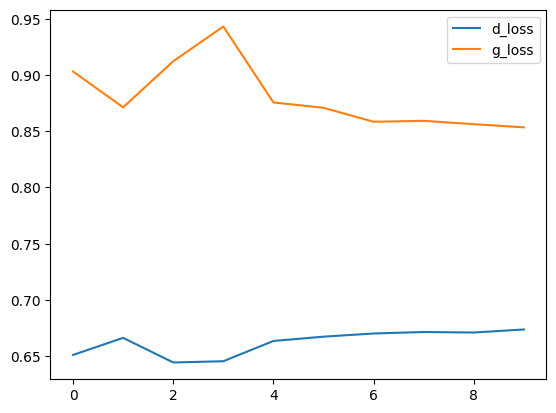

In [6]:
plt.plot(history.history["d_loss"], label="d_loss")
plt.plot(history.history["g_loss"], label="g_loss")
plt.legend()
plt.show()

- 이 그래프는 학습이 안정적으로 진행되고 있다는 좋은 신호를 보여준다.
  - d_loss(파란색)는 0.65 근처에서, g_loss(주황색)는 0.85~0.95 근처에서 둘 다 큰 요동 없이 평평하게 유지되고 있다.
  - 초반 몇 epoch 동안 약간 흔들리다가(2~4 epoch 근처 g_loss가 잠깐 튀어오름), 이후로는 거의 수평선에 가깝게 안정된다.
- GAN 학습에서 최악의 패턴은 둘 중 하나가 완전히 이겨버리는 경우이다.
  - d_loss가 거의 0으로 떨어지고 g_loss가 계속 치솟는 경우 → discriminator가 완승, generator가 학습할 그래디언트를 못 받음 ("새까만 이미지" 가 만들어질 수 있음) - 이 이유로 generator 모델에 BatchNorm layer 삽입이 중요. ( discriminator가 초반에 너무 빨리 강해져서, generator에 전달되는 gradient가 사라지고(discriminator의 sigmoid가 포화됨) generator가 "그냥 아무거나 극단값을 뱉으면 loss가 덜 나쁘다"는 쪽으로 붕괴해버리는 게 GAN의 아주 전형적인 실패 패턴)
  - 반대로 g_loss가 0에 가깝게 떨어지는 경우 → generator가 너무 쉽게 이겨서 discriminator가 무력화됨.
- GAN 손실 그래프를 읽을 때 주의할 점:
  - 일반적인 분류/회귀 모델과 달리, GAN은 loss가 0으로 수렴하는 게 목표가 아니다. loss가 어느 값에서 "안정적으로 유지되는 것" 자체가 성공 신호이고, 오히려 한쪽이 0으로 급격히 떨어지면 그게 문제(collapse)가 된다.
  - 본 그래프는 그 "건강한 균형" 사례를 잘 보여주는 예를 보여준다.

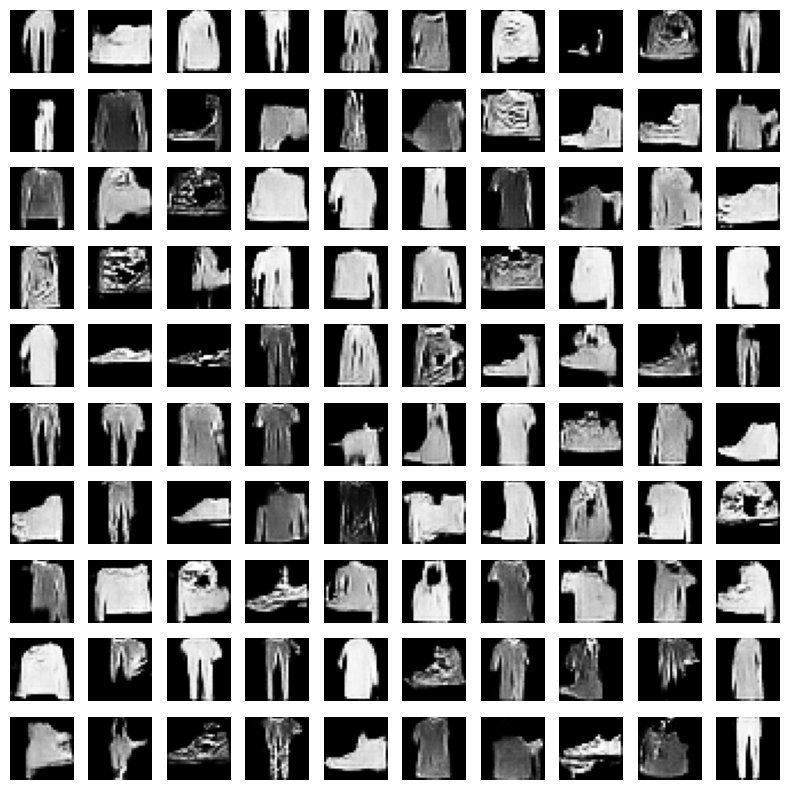

In [7]:
gan.generator.save("generator.keras")   # .h5 대신 .keras (Keras 3 권장 포맷)

loaded_generator = keras.models.load_model("generator.keras")

n = 10
random_latent_vectors = tf.random.normal(shape=(n * n, latent_dim))
generated_images = loaded_generator.predict(random_latent_vectors, verbose=0)
generated_images = (generated_images * 127.5 + 127.5).astype("uint8")

fig, axes = plt.subplots(n, n, figsize=(8, 8))
for i, ax in enumerate(axes.flat):
    ax.imshow(generated_images[i, :, :, 0], cmap="gray")
    ax.axis("off")
plt.tight_layout()
plt.show()

# Exercise

- @property: 메서드를 "함수처럼 호출"하지 않고 "속성처럼 접근"할 수 있게 만들어주는 데코레이터

In [2]:
class Foo:
    def bar(self):        # 그냥 메서드
        return 42

class Baz:
    @property
    def bar(self):         # property로 선언
        return 42

Foo().bar()   # 42 — 괄호를 붙여서 "호출"해야 함

42

In [3]:
Baz().bar     # 42 — 괄호 없이 "속성처럼" 접근

42

- keras.metrics.Mean() — 상태 있음 (stateful)
  - 여러 번에 걸쳐 누적해서 평균을 추적하는 상태를 가진 객체
  - 내부적으로 "지금까지 몇 번 호출됐는지"와 "누적 합"을 기억하고 있다가, result()를 부르면 그 누적 평균을 돌려준다.

In [8]:
tracker = keras.metrics.Mean()
tracker.update_state(0.9)   # 지금까지 평균: 0.9
tracker.update_state(0.7)   # 지금까지 평균: (0.9+0.7)/2 = 0.8
tracker.update_state(0.5)   # 지금까지 평균: (0.9+0.7+0.5)/3 = 0.7
tracker.result()            # 0.7

<tf.Tensor: shape=(), dtype=float32, numpy=0.699999988079071>

In [9]:
tracker.reset_state()       # 누적값 초기화 (다음 epoch을 위해)
tracker.result()

<tf.Tensor: shape=(), dtype=float32, numpy=0.0>

- super() : "부모 클래스의 메서드를 (내가 재정의하기 전) 원래 버전 그대로 실행해달라"는 뜻

In [10]:
class Parent:
    def greet(self):
        print("Parent의 인사")

class Child(Parent):
    def greet(self):
        super().greet()          # Parent.greet()를 그대로 실행
        print("Child의 인사")

Child().greet()
# 출력:
# Parent의 인사
# Child의 인사

Parent의 인사
Child의 인사
